In [2]:
from sklearn.datasets import fetch_openml

In [4]:
data = fetch_openml("vertebra-column")

/home/fampkin/Desktop/ML/venv/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name vertebra-column exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1523
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1524

  warn(warning_msg)


In [7]:
data.DESCR

"**Author**: Guilherme de Alencar Barreto, Ajalmar R. da Rocha Neto, Henrique Antonio Fonseca da Mota Filho       \n**Source**: UCI  \n**Please cite**:   \n\n* Dataset Title: Vertebra Column - 3 classes\n\n* Abstract:   \nData set containing values for six biomechanical features used to classify orthopaedic patients into 3 classes (normal, disk hernia or spondilolysthesis) or 2 classes (normal or abnormal).\n\n* Source:\n\nGuilherme de Alencar Barreto (guilherme '@' deti.ufc.br) & Ajalmar R. da Rocha Neto (ajalmar '@' ifce.edu.br), Department of Teleinformatics Engineering, Federal University of Ceará, Fortaleza, Ceará, Brazil. \n\nHenrique Antonio Fonseca da Mota Filho (hdamota '@' gmail.com), Hospital Monte Klinikum, Fortaleza, Ceará, Brazil.\n\n\nData Set Information:\n\nBiomedical data set built by Dr. Henrique da Mota during a medical residence period in the Group of Applied Research in Orthopaedics (GARO) of the Centre Médico-Chirurgical de Réadaptation des Massues, Lyon, France.

Первая задача состоит в том, чтобы классифицировать пациентов по принадлежности к одной из трех категорий: нормальные (100 пациентов), межпозвоночные грыжи (60 пациентов) или спондилолистез (150 пациентов). Для выполнения второго задания категории "Грыжа межпозвоночного диска" и "спондилолистез" были объединены в одну категорию, обозначенную как "аномалия". Таким образом, вторая задача состоит в том, чтобы классифицировать пациентов по принадлежности к одной из двух категорий: нормальным (100 пациентов) или ненормальным (210 пациентов).

Т.е нам нужно обучить 2 модели классификации для определения принадлежности пациентов к одной из групп. Первая модель для первой задачи, вторая для второй



In [25]:
data.data

,V1,V2,V3,V4,V5,V6
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501
...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750


In [12]:
data.feature_names

['V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [15]:
y = data.target
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: category
Categories (3, object): ['1', '2', '3']

In [16]:
X = data.data
X.head()

,V1,V2,V3,V4,V5,V6
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501


(array([ 60.,   0.,   0.,   0.,   0., 150.,   0.,   0.,   0., 100.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

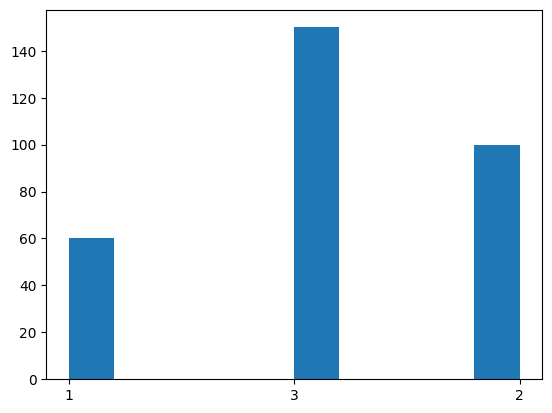

In [17]:
import matplotlib.pyplot as plt
plt.hist(y)

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      310 non-null    float64
 1   V2      310 non-null    float64
 2   V3      310 non-null    float64
 3   V4      310 non-null    float64
 4   V5      310 non-null    float64
 5   V6      310 non-null    float64
dtypes: float64(6)
memory usage: 14.7 KB


In [19]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 310 entries, 0 to 309
Series name: Class
Non-Null Count  Dtype   
--------------  -----   
310 non-null    category
dtypes: category(1)
memory usage: 574.0 bytes


In [21]:
X.describe()

,V1,V2,V3,V4,V5,V6
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767933
75%,72.877696,22.120395,63.000000,52.695889,125.467675,41.287352
max,129.834041,49.431864,125.742386,121.429566,163.071041,418.543082


In [24]:
y.describe()

count     310
unique      3
top         3
freq      150
Name: Class, dtype: object

In [26]:
from sklearn.linear_model import LogisticRegression

In [40]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_macro')

print("CV accuracy:", cv_acc.mean(), "+/-", cv_acc.std())
print("CV F1-macro:", cv_f1.mean(), "+/-", cv_f1.std())

model.fit(X_train, y_train)
print("Test score (accuracy):", model.score(X_test, y_test))  # это и есть score()
print("Test F1-macro:", f1_score(y_test, model.predict(X_test), average='macro'))


CV accuracy: 0.8667755102040816 +/- 0.04922970155507751
CV F1-macro: 0.8281312088494428 +/- 0.06462704853234208
Test score (accuracy): 0.8225806451612904
Test F1-macro: 0.774172263461765


score в линейной классификации - метрика accuracy которая показывает точность определения нужного класса

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy (score):", model.score(X_test, y_test))
print("Precision macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred, average='macro'))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))


Accuracy (score): 0.8225806451612904
Precision macro: 0.7772005772005771
Recall macro: 0.7722222222222221
F1 macro: 0.774172263461765


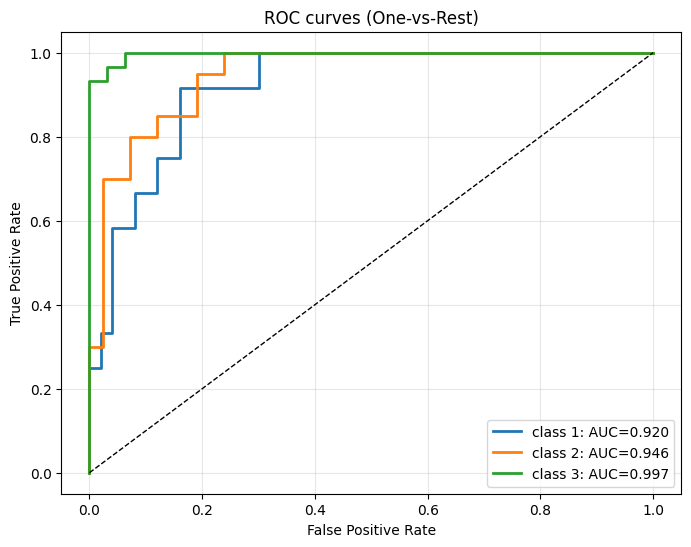

AUC per class: {'1': 0.9199999999999999, '2': 0.9464285714285714, '3': 0.996875}
Micro AUC:    0.9692
Macro AUC:    0.9544
Weighted AUC: 0.9657
Best threshold per class (Youden J):
  class 1: 0.2807
  class 2: 0.1554
  class 3: 0.3677


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score

# model уже обучен
proba = model.predict_proba(X_test)      # shape: (n_samples, n_classes)
classes = model.classes_

# binarize y_test для one-vs-rest ROC
lb = LabelBinarizer()
lb.fit(classes)
y_test_bin = lb.transform(y_test)

# если binary, transform дает 1 столбец -> сделаем 2 столбца
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(8, 6))

auc_per_class = {}
best_thr_per_class = {}

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc

    # оптимальный порог по критерию Youden's J = TPR - FPR
    j = tpr - fpr
    idx = np.argmax(j)
    best_thr_per_class[cls] = thresholds[idx]

    plt.plot(fpr, tpr, lw=2, label=f'class {cls}: AUC={roc_auc:.3f}')

# micro-average ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

# macro/weighted AUC
auc_macro = roc_auc_score(y_test_bin, proba, average='macro')
auc_weighted = roc_auc_score(y_test_bin, proba, average='weighted')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves (One-vs-Rest)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('AUC per class:', auc_per_class)
print(f'Micro AUC:    {auc_micro:.4f}')
print(f'Macro AUC:    {auc_macro:.4f}')
print(f'Weighted AUC: {auc_weighted:.4f}')
print('Best threshold per class (Youden J):')
for cls, thr in best_thr_per_class.items():
    print(f'  class {cls}: {thr:.4f}')
